In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib as plt
import joblib
import time
import warnings

from itertools import combinations
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [2]:
# This code is responsible to create a championshipFile.csv in which all the groups is represented in each column with 4 teams
def createChampionshipFile():
    #Create csv file for championshipFile
    data = {
        'Group1': ['Senegal', 'Qatar', 'Netherlands', 'Ecuador'],
        'Group2': ['Iran', 'England', 'USA', 'Wales'],
        'Group3': ['Argentina', 'Saudi Arabia', 'Mexico', 'Poland'],
        'Group4': ['Denmark', 'Tunisia', 'France', 'Australia'],
        'Group5': ['Germany', 'Japan', 'Spain', 'Costa Rica'],
        'Group6': ['Morocco', 'Croatia', 'Belgium', 'Canada'],
        'Group7': ['Switzerland', 'Cameroon', 'Brazil', 'Serbia'],
        'Group8': ['Uruguay', 'South Korea', 'Portugal', 'Ghana']
    }

    championship_df = pd.DataFrame(data)

    # Save the DataFrame to a CSV file
    championship_df.to_csv('championshipFile.csv', index=False)

#     print("championshipFile.csv has been created.")

In [2]:
# Global Variables
dataFolder = 'ChampionShipData'
groupFolder = 'GroupStage'
knockoutFolder = 'Knockout'
model_filename = 'RegressorRF.joblib'
rera=pd.read_csv('rera.csv')
DropList=['Unnamed: 0', 'date', 'home_team', 'away_team', 'tournament', 'city', 'country','neutral', 'avg_points_last_5_direct','win_by']

In [1]:
# Function to generate match schedule
def generate_match_schedule(teams):
    matches = list(combinations(teams, 2))
    match_schedule = [{'match_number': i+1, 'home_team': match[0], 'away_team': match[1], 'result': None} for i, match in enumerate(matches)]
    return pd.DataFrame(match_schedule)

# Function to create point table
def create_point_table(teams):
    point_table = [{'teamname': team, 'wins': 0, 'loss': 0, 'draws': 0, 'points': 0} for team in teams]
    return pd.DataFrame(point_table)

# this function creates 2 files for each group one matchtable and one point table 
# in match table matches are created and arrange for all the teams in that group that each team plays against all team in groups 
# one in group Round. Also the points table represent the statistics of all the teams in that group
def createGroupFolderAndFiles():
    # Create ChampionShipData/GroupStage folders if not exists
    os.makedirs(os.path.join(dataFolder, groupFolder), exist_ok=True)

    # Load championship data
    championship_df = pd.read_csv('championshipFile.csv')

    # Create point table and match table for each group
    for group_name in championship_df.columns:
        # Skip non-group columns
        if 'Group' not in group_name:
            continue

        group_teams = championship_df[group_name].tolist()

        # Create point table
        point_table = create_point_table(group_teams)
        point_table.to_csv(os.path.join(dataFolder, groupFolder, f'pointTable_{group_name}.csv'), index=False)

        # Create match table
        match_schedule = generate_match_schedule(group_teams)
        match_schedule.to_csv(os.path.join(dataFolder, groupFolder, f'matchTable_{group_name}.csv'), index=False)

#     print(f"Point tables and Match tables created for each group and saved in the '{os.path.join(dataFolder, groupFolder)}' folder.")


In [5]:
# Load the saved model from a file
loaded_model = joblib.load(model_filename)

In [6]:
# This function is repsoible to predict the probabilities of draw, win, lose , in macth between two teams
# we used a technique that we get the two random sample from rera, one for each team and the get the average of that after 
# this operation we get single record to input the model

# Placeholder function for predicting match outcome
def predict_match_outcome(home_team_data, away_team_data,DropList, trained_model):
    if DropList is None:
        DropList = []  # Default to an empty list if not provided

    # Drop specified columns
    home_team_data = home_team_data.drop(columns=DropList)
    away_team_data = away_team_data.drop(columns=DropList)

    # Concatenate the home and away team data for averaging
    input_data = pd.concat([home_team_data, away_team_data]).mean().to_numpy().reshape(1, -1)

    # Perform prediction using the trained model
    probabilities = trained_model.predict_proba(input_data)

    return probabilities[0]

In [7]:
# The Macthes Function is responsible to play the all macthes in represented by file of each round, matchtable or konckoutmatchtable
# then get the results and store them in  the results column 
def Matches(Folder,filename):
    # Iterate over match tables in the GroupStage folder
    for file in os.listdir(os.path.join(dataFolder, Folder)):
        if file.startswith(filename):
            # Load match table
            match_table = pd.read_csv(os.path.join(dataFolder, Folder, file))

            # Iterate over each row in the match table
            for index, match_row in match_table.iterrows():
                home_team = match_row['home_team'] #france
                away_team = match_row['away_team'] #australia

                # Filter rows based on home_team and away_team from the 'rera' dataset
                home_team_data = rera[(rera['home_team'] == home_team)] # list of all the mactches played by france
                away_team_data = rera[(rera['home_team'] == away_team)] 

                if not home_team_data.empty and not away_team_data.empty:

                    # Randomly select one row from each team's data
                    selected_home_row = home_team_data.sample(n=1)
                    selected_away_row = away_team_data.sample(n=1)

                    # Perform model prediction
                    prediction = predict_match_outcome(selected_home_row, selected_away_row,DropList,loaded_model)

                    # Assign the index of the highest probability to the 'result' column
                    if filename == 'knockout_schedule' :
                        match_table.at[index, 'result'] = (np.argmax(prediction[1:]))+1 # 1,2
                    else:
                        match_table.at[index, 'result'] = np.argmax(prediction)

            # Save the modified match table with results
            match_table.to_csv(os.path.join(dataFolder, Folder, file), index=False)

#     print("Match results updated and saved.")


In [8]:
# this function is resposbible to update the points table for each group and then for knoxkout macthes which then reorganize
# the data in way that top team having high goals put on top of table, whiwh then helps to extract the data for next round
# for eligble team
def setPointsTables(folder,filename):
    # Iterate over match tables in the GroupStage folder
    for file in os.listdir(os.path.join(dataFolder, folder)):
        if file.startswith(filename):
            # Load match table
            match_table = pd.read_csv(os.path.join(dataFolder, folder, file))

            # Initialize a dictionary to store team statistics
            team_stats = {}

            # Iterate over each row in the match table
            for _, match_row in match_table.iterrows():
                home_team = match_row['home_team']
                away_team = match_row['away_team']
                result = match_row['result']

                # Update home team statistics
                team_stats.setdefault(home_team, {'wins': 0, 'draws': 0, 'loses': 0})
                if result == 1:
                    team_stats[home_team]['wins'] += 1
                elif result == 0:
                    team_stats[home_team]['draws'] += 1
                else:
                    team_stats[home_team]['loses'] += 1

                # Update away team statistics
                team_stats.setdefault(away_team, {'wins': 0, 'draws': 0, 'loses': 0})
                if result == 2:
                    team_stats[away_team]['wins'] += 1
                elif result == 0:
                    team_stats[away_team]['draws'] += 1
                else:
                    team_stats[away_team]['loses'] += 1

            # Calculate points for each team
            points_data = []
            for team, stats in team_stats.items():
                wins = stats['wins']
                draws = stats['draws']
                loses = stats['loses']

                # Calculate total points
                total_points = wins * 3 + draws * 1 + loses * 0

                # Append team data to points_data
                points_data.append({'teamname': team, 'wins': wins, 'draws': draws, 'loses': loses, 'points': total_points})

            # Create a DataFrame from points_data
            points_table = pd.DataFrame(points_data)

            # Sort the DataFrame based on the 'points' column in descending order
            points_table = points_table.sort_values(by='points', ascending=False).reset_index(drop=True)
            
            if file.startswith('matchTable_Group'):
                name=f'pointTable_{file[11:17]}.csv'
            else:
                name='knockout_point_table.csv'
            
            # Save the updated points table to a file
            points_table.to_csv(os.path.join(dataFolder, folder, name), index=False)

#     print("Points tables updated and saved.")


In [9]:
# this function reposbile to generateor schedule the matches between all qualified team of rprevious round
# Function to generate knockout match schedule
def generate_knockout_schedule(teams,g):
    matches = []
    n = len(teams)
    d=1
    for i in range(0, n, g):
        part_teams = teams[i:i+g]
        match = {
            'match_number': d,
            'home_team': part_teams[0],
            'away_team': part_teams[3],
            'result': None
        }
        matches.append(match)
        d+=1
        match = {
            'match_number': d,
            'home_team': part_teams[1],
            'away_team': part_teams[2],
            'result': None
        }
        matches.append(match)
        d+=1
    return pd.DataFrame(matches)

In [10]:
# This code is repsosible to create matchtable and pointstable files for each knockout
def createKnockout(knockOut):
    # Create folders if not exists
    os.makedirs(os.path.join(dataFolder, f'{knockoutFolder}{knockOut+1}'), exist_ok=True)

    # Load point tables for each group
    point_tables = {}
    for group_name in os.listdir(os.path.join(dataFolder, groupFolder)):
        if group_name.startswith('pointTable_Group'):
            point_table = pd.read_csv(os.path.join(dataFolder, groupFolder, group_name))
            point_tables[group_name] = point_table

    top_teams = []

    # Extract top two teams from each group for knockout1
    if knockOut == 0:
        for group_name, point_table in point_tables.items():
            top_teams.extend(point_table.nlargest(2, 'points')['teamname'])

    else:
        # Extract top N teams from knockout point table
        knockout_point_table = pd.read_csv(os.path.join(dataFolder, f'{knockoutFolder}{knockOut}', 'knockout_point_table.csv'))
        top_teams = (knockout_point_table.nlargest(len(knockout_point_table)//2, 'points')['teamname']).tolist()

    # print(top_teams)
    if len(top_teams) >= 4:
        # Generate knockout match schedule
        knockout_schedule = generate_knockout_schedule(top_teams,4)
        knockout_schedule.to_csv(os.path.join(dataFolder, f'{knockoutFolder}{knockOut+1}', 'knockout_schedule.csv'), index=False)
        
    else:
        match = [{
            'match_number': 1,
            'home_team': top_teams[0],
            'away_team': top_teams[1],
            'result': None
        }]
        knockout_schedule = pd.DataFrame(match)
        knockout_schedule.to_csv(os.path.join(dataFolder, f'{knockoutFolder}{knockOut+1}', 'knockout_schedule.csv'), index=False)
        

    # Create points table for knockout teams
    knockout_point_table = pd.DataFrame({'teamname': top_teams, 'wins': 0, 'loss': 0, 'draws': 0, 'points': 0})
    knockout_point_table.to_csv(os.path.join(dataFolder, f'{knockoutFolder}{knockOut+1}', 'knockout_point_table.csv'), index=False)

#     print(f"Knockout {knockOut+1} schedule and points table created and saved in the '{knockoutFolder}{knockOut+1}' folder.")

In [12]:
#Show the Winner
def winner():
    win=pd.read_csv('.\ChampionShipData\Knockout4\knockout_schedule.csv')
    homeTeam=win['home_team'][0]
    awayTeam=win['away_team'][0]
    result=win['result'][0]
    if(result == 1): final=homeTeam
    else: final=awayTeam
    print(' Final Football Match')
    print(' '+homeTeam+'  Vs  '+awayTeam+' ')
    print('______________________________')
    print('______________________________')
    print(' Winner: '+final)
    print()

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def displayGroupPoints(folder, filename):
    dfs = []

    # Iterate over match tables in the GroupStage folder
    for file in os.listdir(os.path.join(dataFolder, folder)):
        if file.startswith(filename):
            # Load match table
            dfs.append(pd.read_csv(os.path.join(dataFolder, folder, file)))

    # Create a 4x2 grid of subplots
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 6))

    # Flatten the 2D array of subplots to iterate over them
    axes = axes.flatten()

    # Iterate through the list of DataFrames and add to subplots
    for i, ax in enumerate(axes):
        ax.axis('off')  # Optional: Turn off axis for a cleaner look
        if i < len(dfs):
            # Use ax.table with values as a 2D array to display the DataFrame content
            ax.table(cellText=dfs[i].values, colLabels=dfs[i].columns, cellLoc='center', loc='center')
            ax.set_title(f'Table {i + 1}')

    # Adjust layout to prevent clipping
    plt.tight_layout()
    plt.show()


In [8]:
import os
import pandas as pd

# Assuming 'dataFolder' is defined elsewhere in your code
# dataFolder = '/path/to/your/data/folder'

def extract_knockout_data():
    knockoutFolder = 'Knockout'
    matchFile='knockout_schedule.csv'
    knockout_data = []

    # Iterate over match tables in the specified knockout folder
    for i in range(1,4):
        for file in os.listdir(os.path.join(dataFolder, knockoutFolder+str(i))):
            if file.startswith(f'knockout_schedule'):
                # Load match table
                match_table = pd.read_csv(os.path.join(dataFolder, knockoutFolder+str(i), file))

                # Print or process match data
                print(f"knockout_schedule : "+str(i))
                print(match_table)
                print("\n")

                # Append match data to the list
                knockout_data.append(match_table)

    return knockout_data

## Championship Summary
`The function runChampionShip orchestrates a championship tournament. It begins by creating a championship file and establishing folders and files for group stage matches. Subsequently, it initiates group stage matches and sets up points tables to track team performance. The process then enters a loop iterating four times to simulate knockout rounds. Within each iteration, it creates knockout schedules, conducts matches, and updates points tables for the respective knockout stage. Finally, the function determines the tournament winner. This script encapsulates the entire workflow of a championship, seamlessly progressing from group stages to knockout rounds, ultimately culminating in the declaration of the tournament's victor. The modular structure of the code enhances readability and allows for easy maintenance or customization of tournament parameters.`

In [9]:
def runChampionShip():
    createChampionshipFile()
    createGroupFolderAndFiles()
    Matches(groupFolder,'matchTable_Group')
    setPointsTables(groupFolder,'matchTable_Group')
    for i in range(4):
        createKnockout(i)
        Matches(knockoutFolder+str(i+1),'knockout_schedule')
        setPointsTables(knockoutFolder+str(i+1),'knockout_schedule')
    displayGroupPoints(groupFolder, 'pointTable_Group')
    extract_knockout_data()
    winner()


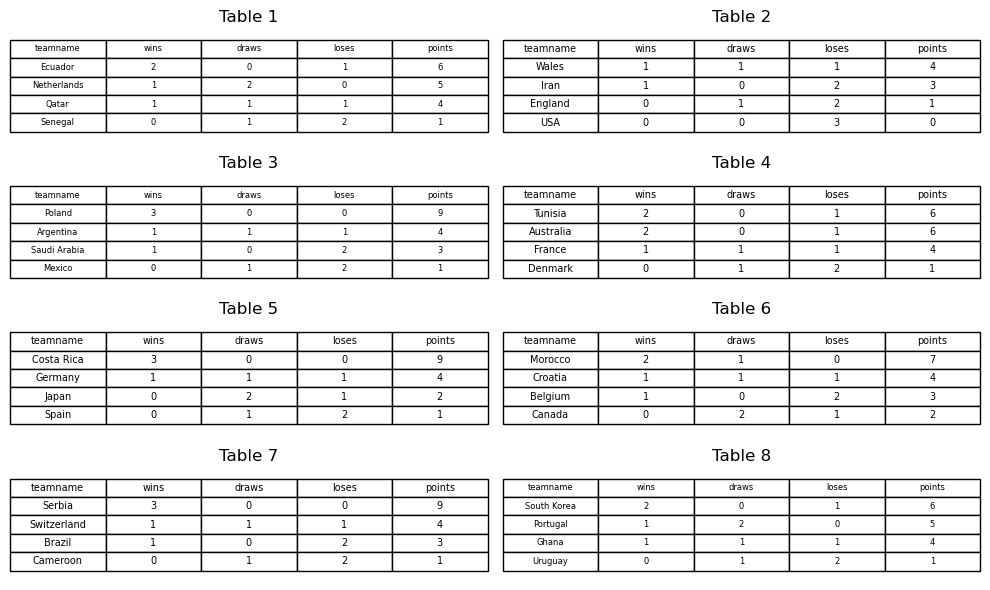

knockout_schedule : 1
   match_number    home_team    away_team  result
0             1      Ecuador         Iran     1.0
1             2  Netherlands        Wales     2.0
2             3       Poland    Australia     1.0
3             4    Argentina      Tunisia     1.0
4             5   Costa Rica      Croatia     2.0
5             6      Germany      Morocco     2.0
6             7       Serbia     Portugal     1.0
7             8  Switzerland  South Korea     2.0


knockout_schedule : 2
   match_number home_team    away_team  result
0             1   Ecuador    Argentina     2.0
1             2     Wales       Poland     2.0
2             3   Croatia  South Korea     1.0
3             4   Morocco       Serbia     2.0


knockout_schedule : 3
   match_number  home_team away_team  result
0             1  Argentina    Serbia     1.0
1             2     Poland   Croatia     2.0


 Final Football Match
 Argentina  Vs  Croatia 
______________________________
______________________________

In [13]:
# Suppress warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    runChampionShip()